In [1]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [2]:
data = pd.read_csv('C:/MAFAS/APU/CT046-3-M-AML/CT046 - LABS/Python LAB MATERIALS/Lab 10 - RF/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
data.shape

(768, 9)

In [5]:
# Descriptive statistics
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


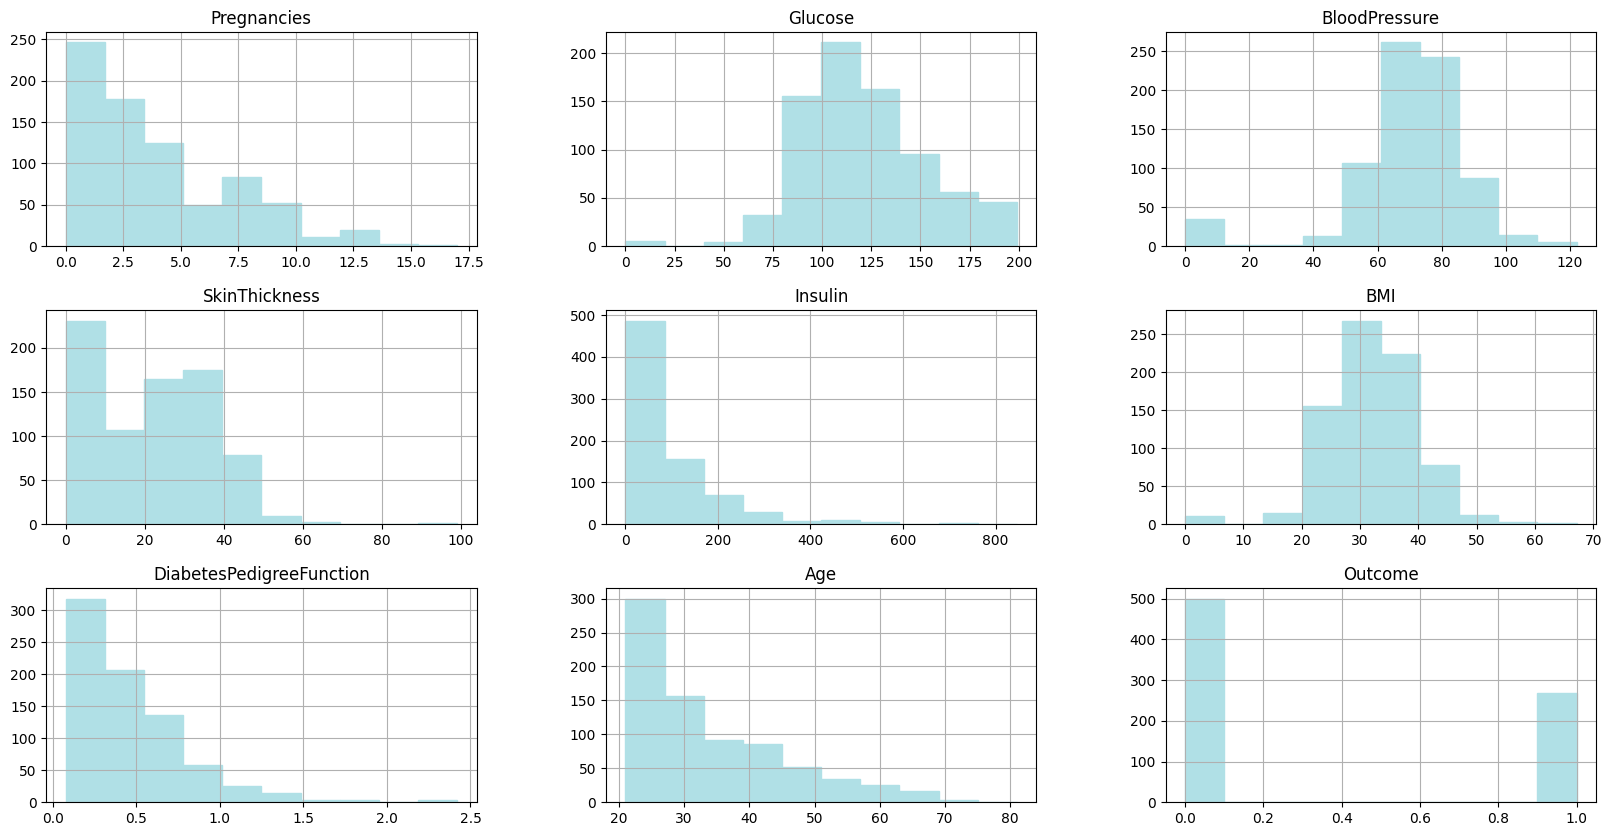

In [6]:
import matplotlib.pyplot as plt
data.hist(figsize = (20,10), edgecolor = "powderblue", color = "powderblue")
plt.show()

<Axes: xlabel='Outcome', ylabel='count'>

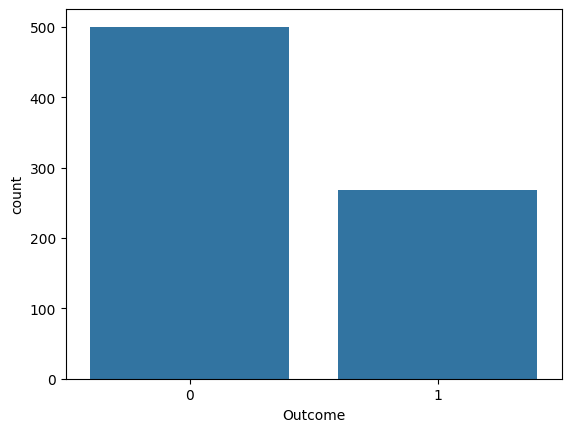

In [7]:
import seaborn as sns
data['Outcome'].value_counts()
sns.countplot(x = 'Outcome', data = data)

In [8]:
x = data.drop('Outcome', axis=1)
y = data['Outcome']

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

**Class Balancing**

Counter({0: 401, 1: 401})


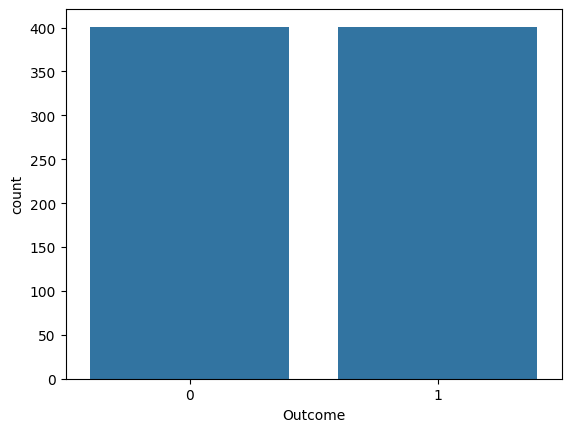

In [10]:
from collections import Counter
from imblearn.over_sampling import SMOTE
x_train_b, y_train_b = SMOTE().fit_resample(x_train, y_train)
sns.countplot(x = y_train_b, data = data)
print(Counter(y_train_b))

**RF Base model**

In [11]:
rf = RandomForestClassifier()
rf.fit(x_train_b, y_train_b)

y_pred = rf.predict(x_test)

# Get the evaluation metrics
rf_acc = accuracy_score(y_test, y_pred)*100
rf_pre = precision_score(y_test, y_pred, average = 'weighted')
rf_recall = recall_score(y_test, y_pred, average = 'weighted')
rf_f1_ = f1_score(y_test, y_pred, average = 'weighted') 

print("\nRF - Accuracy: {:.3f}.".format(rf_acc))
print("RF - Precision: {:.3f}.".format(rf_pre))
print("RF - Recall: {:.3f}.".format(rf_recall))
print("RF - F1_Score: {:.3f}.".format(rf_f1_))
print ('\n Classification Report:\n', classification_report(y_test, y_pred))


RF - Accuracy: 69.481.
RF - Precision: 0.728.
RF - Recall: 0.695.
RF - F1_Score: 0.701.

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.67      0.74        99
           1       0.55      0.75      0.64        55

    accuracy                           0.69       154
   macro avg       0.69      0.71      0.69       154
weighted avg       0.73      0.69      0.70       154



**Important Features ~~~~~~~~~~~~~~~~~~**

This is can be obtained using the RF base model. 

This is a very useful output which helps to identify the most significant IVs in predicting the TV.

                          Importance
Pregnancies                 0.074387
Glucose                     0.247512
BloodPressure               0.082448
SkinThickness               0.069376
Insulin                     0.070137
BMI                         0.192906
DiabetesPedigreeFunction    0.122747
Age                         0.140488



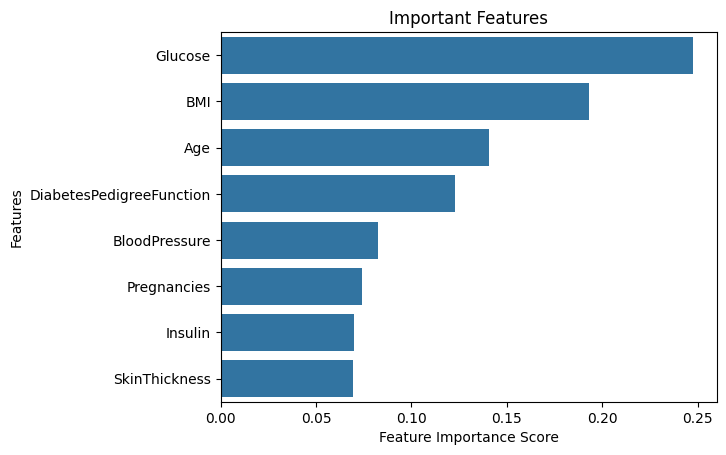

In [12]:
importance = rf.feature_importances_
importance_df = pd.DataFrame(importance, index = x_train_b.columns, columns = ["Importance"])
print(importance_df)
print()

import matplotlib.pyplot as plt
feature_imp = pd.Series(rf.feature_importances_, index = x_train_b.columns).sort_values(ascending = False)

# Creating a bar plot, displaying only the top k features
sns.barplot(x = feature_imp[:10], y = feature_imp.index[:10])

# Add labels to your graph
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Important Features")
plt.show()

**RF - Random Search CV with Class Balancing**

In [13]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits = 7, shuffle = True, random_state = 42)

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from numpy import arange
from scipy.stats import randint

# Create the parameter grid
parameters = {'criterion': ['gini', 'entropy', 'log_loss'],
               'n_estimators': randint(200, 600),
               'max_features': ['log2', 'sqrt'],
               'max_depth': [None] + list(arange(10, 110, 10)),
               'min_samples_split': randint(2, 10),
               'min_samples_leaf': randint(1, 6),
               'bootstrap': [True, False]
               }

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = parameters, n_iter = 100, cv = skf, scoring = 'accuracy', random_state = 42)

rf_random.fit(x_train_b, y_train_b)

print("\nBest Parameters: ", rf_random.best_params_)
print("Best Scores: ", rf_random.best_score_) 

best_rf = rf_random.best_estimator_

y_pred = best_rf.predict(x_test)

# Get the accuracy score
rf_acc = accuracy_score(y_test, y_pred)*100
rf_pre = precision_score(y_test, y_pred, average = 'micro')
rf_recall = recall_score(y_test, y_pred, average = 'micro')
rf_f1_ = f1_score(y_test, y_pred, average = 'micro')

print("\nRF - Accuracy: {:.3f}.".format(rf_acc))
print("RF - Precision: {:.3f}.".format(rf_pre))
print("RF - Recall: {:.3f}.".format(rf_recall))
print("RF - F1_Score: {:.3f}.".format(rf_f1_))
print ('\n Classification Report:\n', classification_report(y_test, y_pred))


Best Parameters:  {'bootstrap': False, 'criterion': 'entropy', 'max_depth': np.int64(80), 'max_features': 'log2', 'min_samples_leaf': 4, 'min_samples_split': 5, 'n_estimators': 307}
Best Scores:  0.826697177726926

RF - Accuracy: 74.026.
RF - Precision: 0.740.
RF - Recall: 0.740.
RF - F1_Score: 0.740.

 Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.62      0.71      0.66        55

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.73       154
weighted avg       0.75      0.74      0.74       154



**Lab Exercise:**

Try Grid Search with Class balancing and report the results.